# 📄 Day 20 – Document Boundary Detection Tool
**Canny + Morphological Ops + Contour Detection**

**Name:** Azeem Naseer | **Date:** 2026-07-08

This tool detects the boundary of a document in an image using:
1. Grayscale conversion
2. Gaussian Blur
3. Canny Edge Detection
4. Morphological Operations (noise removal)
5. Contour Detection → Largest contour = document boundary

In [1]:
!pip install opencv-python-headless matplotlib -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

os.makedirs('output', exist_ok=True)

def show_grid(images, titles, cols=4, figsize=(20, 5), suptitle=None):
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight='bold')
    axes = np.array(axes).flatten()
    for ax, img, title in zip(axes, images, titles):
        if len(img.shape) == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.axis('off')
    for ax in axes[len(images):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('✅ Setup complete!')

✅ Setup complete!


## 📋 Core Function – detect_document_boundary()
This single function runs the entire pipeline.

In [2]:
def detect_document_boundary(image_path, canny_low=30, canny_high=100,
                              kernel_size=5, show_steps=True, save_output=True):
    """
    Detect document boundary in an image.

    Args:
        image_path  : Path to input image
        canny_low   : Lower Canny threshold (default 30)
        canny_high  : Upper Canny threshold (default 100)
        kernel_size : Morphological kernel size (default 5)
        show_steps  : Display intermediate steps
        save_output : Save result to output/

    Returns:
        result_img  : Image with boundary drawn
        contour     : Detected document contour (or None)
    """
    # ── STEP 1: Load ─────────────────────────────────────────
    img = cv2.imread(image_path)
    if img is None:
        print(f'❌ Cannot load: {image_path}')
        return None, None

    h, w = img.shape[:2]
    print(f'\n📄 Processing: {image_path}  ({w}×{h})')

    # ── STEP 2: Grayscale ─────────────────────────────────────
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ── STEP 3: Gaussian Blur ─────────────────────────────────
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # ── STEP 4: Canny Edge Detection ──────────────────────────
    # Auto thresholds from median pixel value
    median_val  = np.median(blurred)
    sigma       = 0.33
    auto_low    = int(max(0,   (1.0 - sigma) * median_val))
    auto_high   = int(min(255, (1.0 + sigma) * median_val))
    edges = cv2.Canny(blurred,
                      min(canny_low,  auto_low),
                      max(canny_high, auto_high))

    # ── STEP 5: Morphological Operations ──────────────────────
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    # Close gaps in document edges
    closed  = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)
    # Remove small noise
    cleaned = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel, iterations=1)
    # Dilate to connect nearby edges
    dilated = cv2.dilate(cleaned, kernel, iterations=1)

    # ── STEP 6: Find Contours ─────────────────────────────────
    contours, _ = cv2.findContours(
        dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    result = img.copy()
    doc_contour = None

    if contours:
        # Sort by area — largest = document
        contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
        doc_contour     = contours_sorted[0]
        area            = cv2.contourArea(doc_contour)
        img_area        = h * w
        coverage        = area / img_area * 100

        # Approximate the contour to a polygon
        peri   = cv2.arcLength(doc_contour, True)
        approx = cv2.approxPolyDP(doc_contour, 0.02 * peri, True)

        # Draw the detected boundary
        cv2.drawContours(result, [approx], -1, (0, 255, 0), 3)

        # Draw corner points
        for point in approx:
            cv2.circle(result, tuple(point[0]), 8, (0, 0, 255), -1)

        # Add info overlay
        cv2.putText(result, f'Boundary: {len(approx)} corners',
                    (15, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
        cv2.putText(result, f'Coverage: {coverage:.1f}%',
                    (15, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

        print(f'  ✅ Document detected!')
        print(f'     Corners  : {len(approx)}')
        print(f'     Area     : {area:,.0f} px² ({coverage:.1f}% of image)')
        print(f'     Is quad? : {"Yes (likely document)" if len(approx) == 4 else "No (complex shape)"}')
    else:
        cv2.putText(result, 'No boundary detected', (15, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)
        print('  ⚠️  No contours found — try adjusting Canny thresholds')

    # ── STEP 7: Show Pipeline Steps ───────────────────────────
    if show_steps:
        show_grid(
            [img, gray, blurred, edges, cleaned, dilated, result],
            ['1. Original', '2. Grayscale', '3. Gaussian Blur',
             '4. Canny Edges', '5. Morphology (Close+Open)',
             '6. Dilated', '7. Detected Boundary'],
            cols=4, figsize=(22, 12),
            suptitle=f'Document Boundary Detection Pipeline – {os.path.basename(image_path)}'
        )

    # ── STEP 8: Save ──────────────────────────────────────────
    if save_output:
        name = os.path.splitext(os.path.basename(image_path))[0]
        cv2.imwrite(f'output/{name}_edges.jpg',    edges)
        cv2.imwrite(f'output/{name}_morphology.jpg', cleaned)
        cv2.imwrite(f'output/{name}_boundary.jpg', result)
        print(f'  ✅ Saved 3 output files to output/')

    return result, doc_contour

print('✅ detect_document_boundary() function ready!')

✅ detect_document_boundary() function ready!


## 🚀 Run on a Sample Document Image


📄 Processing: doc_sample.jpg  (800×600)
  ✅ Document detected!
     Corners  : 3
     Area     : 8,701 px² (1.8% of image)
     Is quad? : No (complex shape)


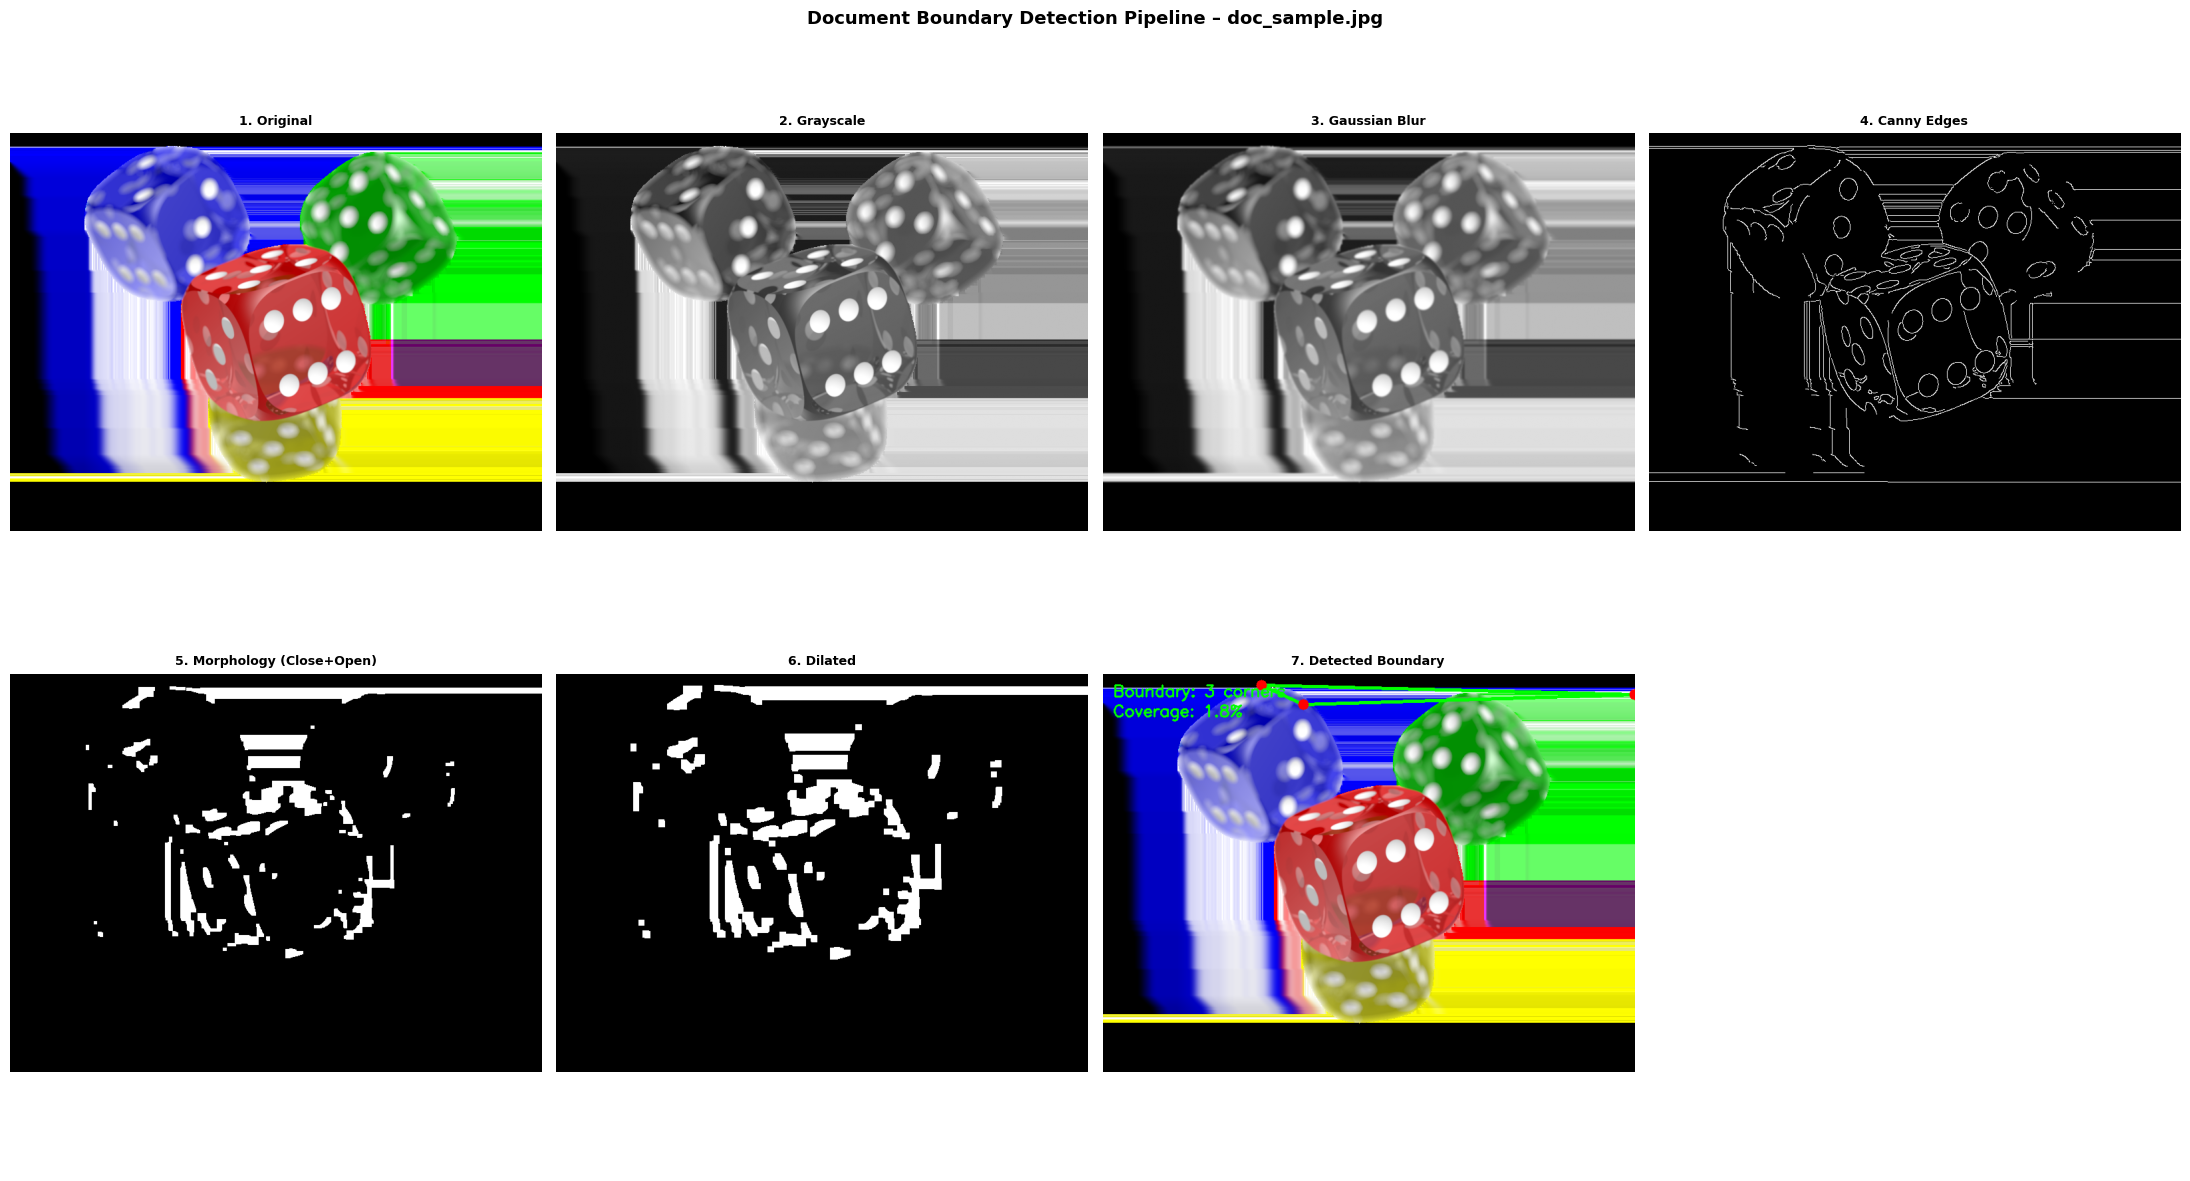

  ✅ Saved 3 output files to output/


In [8]:
# Download a sample document-like image with a User-Agent header
url = 'https://upload.wikimedia.org/wikipedia/commons/4/47/PNG_transparency_demonstration_1.png'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})

with urllib.request.urlopen(req) as response, open('doc_sample.jpg', 'wb') as out_file:
    out_file.write(response.read())

# 📌 To use YOUR own document image:
#    1. Upload it via the Files panel (left sidebar)
#    2. Replace 'doc_sample.jpg' with your filename below

result, contour = detect_document_boundary(
    'doc_sample.jpg',
    canny_low=30,
    canny_high=100,
    kernel_size=5,
    show_steps=True,
    save_output=True
)

## 🎛️ Threshold Experimentation

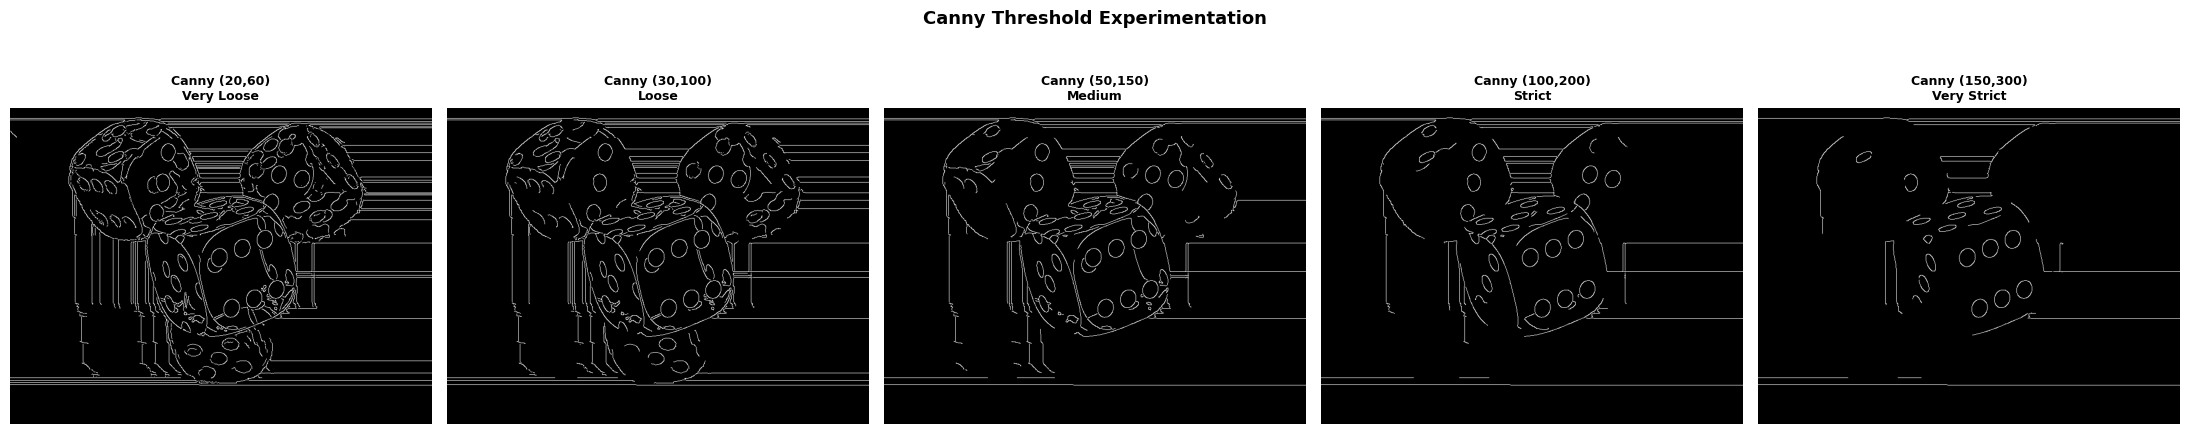

💡 Lower thresholds → more edges (including noise)
💡 Higher thresholds → fewer but stronger edges
💡 Best starting point for documents: low=30, high=100


In [9]:
# Try different Canny threshold combinations
img_exp = cv2.imread('doc_sample.jpg')
gray_exp = cv2.cvtColor(img_exp, cv2.COLOR_BGR2GRAY)
blur_exp = cv2.GaussianBlur(gray_exp, (5, 5), 0)

threshold_pairs = [
    (20, 60,  'Very Loose'),
    (30, 100, 'Loose'),
    (50, 150, 'Medium'),
    (100,200, 'Strict'),
    (150,300, 'Very Strict'),
]

edges_list  = [cv2.Canny(blur_exp, lo, hi) for lo, hi, _ in threshold_pairs]
edge_titles = [f'Canny ({lo},{hi})\n{label}'
               for lo, hi, label in threshold_pairs]

show_grid(edges_list, edge_titles, cols=5, figsize=(22, 5),
          suptitle='Canny Threshold Experimentation')

print('💡 Lower thresholds → more edges (including noise)')
print('💡 Higher thresholds → fewer but stronger edges')
print('💡 Best starting point for documents: low=30, high=100')